# AB Image Pair Description Generator

使用 GPT-4V 为图片对生成变化描述和机器人指令

## 1. 参数配置

在这里配置所有需要的参数

In [ ]:
# =====================================================
# 参数配置区 - 请在这里修改参数
# =====================================================

# OpenAI API Key (必填)
OPENAI_API_KEY = ""

# OpenAI 模型 (gpt-4o, gpt-4o-mini 等)
MODEL = "gpt-5-mini"

# 输入目录，包含 pair_* 文件夹
INPUT_DIR = "/home/lican/workarea/Songwei/synthetic-data-examples/output/livingroom_remove/3_items"

# 最大输出 token 数
MAX_OUTPUT_TOKENS = 8000

## 2. 导入依赖和设置 API Key

In [2]:
import os
import base64
import json
import re
import math
from dataclasses import dataclass
from pathlib import Path
from typing import Any, Dict, List, Optional, Tuple

# 设置 API Key
os.environ["OPENAI_API_KEY"] = OPENAI_API_KEY

from openai import OpenAI

print("依赖导入成功！")

依赖导入成功！


## 3. 数据结构和工具函数

In [3]:
@dataclass
class ObjectSpec:
    """对象规格：包含ID、像素坐标和世界坐标（世界坐标仅用于你在外部计算距离）"""
    object_id: str
    pixel_center_a: Tuple[int, int]
    pixel_center_b: Optional[Tuple[int, int]] = None
    world_coordinate_a: Optional[Tuple[float, float, float]] = None
    world_coordinate_b: Optional[Tuple[float, float, float]] = None
    move_distance_m: Optional[float] = None


def image_to_data_url(image_path: str) -> str:
    """
    将本地图片转换为 data URL，用于 OpenAI API。
    支持格式: PNG/JPEG/WEBP/GIF
    """
    p = Path(image_path)
    if not p.exists():
        raise FileNotFoundError(f"Image not found: {image_path}")

    suffix = p.suffix.lower().lstrip(".")
    mime_map = {
        "png": "image/png",
        "jpg": "image/jpeg",
        "jpeg": "image/jpeg",
        "webp": "image/webp",
        "gif": "image/gif",
    }
    if suffix not in mime_map:
        raise ValueError(f"Unsupported image type: .{suffix}")

    b64 = base64.b64encode(p.read_bytes()).decode("utf-8")
    return f"data:{mime_map[suffix]};base64,{b64}"


def save_json(path: str, obj: Dict[str, Any]) -> None:
    """保存 JSON 文件"""
    Path(path).write_text(json.dumps(obj, ensure_ascii=False, indent=2), encoding="utf-8")


def _euclidean_distance_m(
    a: Tuple[float, float, float],
    b: Tuple[float, float, float],
) -> float:
    """计算 3D 欧氏距离（米）"""
    dx = a[0] - b[0]
    dy = a[1] - b[1]
    dz = a[2] - b[2]
    return math.sqrt(dx * dx + dy * dy + dz * dz)


def _format_distance_m(d: float, decimals: int = 2) -> str:
    """
    将距离格式化为英文自然语言：
    "moved about <distance> m"

    设计说明：
    - 距离数值由外部精确计算，这里只负责语言封装
    - 保留固定小数位，避免模型自行四舍五入或改写
    - 返回的是“可直接复述”的字符串，模型无需再加工
    """
    if d < 0:
        d = 0.0
    return f"moved about {d:.{decimals}f} m"

## 4. Prompt 构建

In [4]:
def build_prompt(objects: List[ObjectSpec]) -> str:
    """
    构建用于“remove”任务的多模态 prompt（严格 JSON 输出）：
    - 只提供一张图片：Image A（移除之前）
    - 你会给模型一份“目标对象列表”，这些 id 对应的对象就是本次变化中“将要消失/被移除”的对象
    - 用 pixel_center_A 仅用于帮助模型在 Image A 中定位正确对象（输出中禁止提及）
    - 输出中按 id 分别生成：消失了什么（description）+ 能导致该消失的单步移除指令（instructions）
    """

    # 1) 构造 Target objects：仅保留 id + pixel_center_A（用于定位）
    obj_entries: List[Dict[str, Any]] = []
    for o in objects:
        entry: Dict[str, Any] = {
            "id": o.object_id,
            "pixel_center_A": [int(o.pixel_center_a[0]), int(o.pixel_center_a[1])],
        }
        obj_entries.append(entry)

    # 2) 将对象列表渲染成 JSON-ish 文本（字段顺序稳定）
    obj_lines: List[str] = []
    for e in obj_entries:
        obj_lines.append(f'  {{"id":"{e["id"]}","pixel_center_A":{e["pixel_center_A"]}}}')
    obj_block = "[\n" + ",\n".join(obj_lines) + "\n]"

    # 3) Prompt：只给 Image A；列表中的对象就是“被移走/消失的对象（变化本身）”
    return f"""
You are given ONE image of a scene: Image A (BEFORE the object(s) were removed).

The target objects listed below are EXACTLY the objects that are missing in the final scene (i.e., they were removed/moved away). 
Your job is to describe what is gone, and write a minimal robot instruction that would cause that disappearance.

Image resolution: 1024 × 768.
Pixel coordinate system (for reference only; INTERNAL USE ONLY):
- Origin (0, 0) is the top-left corner
- x increases to the right, y increases downward

You will receive a list of target objects with pixel centers in Image A.
Use the pixel centers ONLY to locate the correct objects. Do NOT mention pixel centers in your output.

CRITICAL CONSTRAINTS (MUST FOLLOW):
- Return ONLY valid JSON. No markdown. No extra text.
- The coordinate system and resolution are for internal localization ONLY. Do NOT mention them.
- Do NOT include any pixel coordinates or any other numbers in your output.
- Do NOT write any of: "(x=..., y=...)", "x=", "y=", "pixel", "coordinate", "resolution", "approx.", "approximately".
- Describe locations only using natural scene language (e.g., "left side of the counter", "near the stove", "next to the sink", "on the shelf").
- Do NOT mention any objects that are not in the target list.
- If multiple similar objects exist, disambiguate using visible attributes (e.g., color, material, shape), not numbers.

TASK (for EACH target object id):
1) Description:
   - Write ONE short sentence that conveys the object (as seen in Image A) is now gone from the scene.
   - You MAY add relative location details ONLY if it makes the description significantly clearer.

2) Robot instruction:
   - Write ONE concise, single-step imperative instruction that would remove/move away that object from the scene.
   - Keep it minimal (no extra steps).

OUTPUT FORMAT (STRICT JSON):
{{
  "description": [
    {{"id": "<object_id>", "text": ""}},
    ...
  ],
  "instructions": [
    {{"id": "<object_id>", "text": ""}},
    ...
  ]
}}

Target objects (pixel centers are for locating only):
{obj_block}
""".strip()

## 5. 响应解析和验证

In [5]:
def parse_model_output_to_json(text: str) -> Dict[str, Any]:
    """
    鲁棒的 JSON 解析器:
    1) 尝试直接解析
    2) 提取 {...} 块后解析
    3) 回退到旧格式解析
    """
    text = text.strip()

    # 1) 直接解析
    try:
        return json.loads(text)
    except Exception:
        pass

    # 2) 提取 JSON 对象
    m = re.search(r"\{.*\}", text, flags=re.DOTALL)
    if m:
        try:
            return json.loads(m.group(0))
        except Exception:
            pass

    # 3) 回退解析旧格式
    desc_match = re.search(r"description\s*:\s*\[(.*?)\]", text, flags=re.DOTALL | re.IGNORECASE)
    inst_match = re.search(r"instructions\s*:\s*\[(.*?)\]", text, flags=re.DOTALL | re.IGNORECASE)
    if desc_match and inst_match:
        def _parse_list_body(body: str) -> List[str]:
            return re.findall(r"\"(.*?)\"", body, flags=re.DOTALL)

        desc_list = _parse_list_body(desc_match.group(1))
        inst_list = _parse_list_body(inst_match.group(1))
        return {
            "description": [{"id": str(i), "text": t} for i, t in enumerate(desc_list)],
            "instructions": [{"id": str(i), "text": t} for i, t in enumerate(inst_list)],
            "_warning": "Parsed legacy format; IDs are enumerated, not the original object IDs."
        }

    raise ValueError("Failed to parse model output as JSON. Raw text:\n" + text)


def validate_result(result: Dict[str, Any], object_ids: List[str]) -> None:
    """
    验证结果是否包含所有对象。
    """
    desc = result.get("description", [])
    inst = result.get("instructions", [])
    if not isinstance(desc, list) or not isinstance(inst, list):
        raise ValueError("JSON schema error: 'description' and 'instructions' must be lists.")

    if len(desc) != len(inst):
        raise ValueError("JSON schema error: 'description' and 'instructions' length mismatch.")

    got_ids_desc = [x.get("id") for x in desc if isinstance(x, dict)]
    got_ids_inst = [x.get("id") for x in inst if isinstance(x, dict)]
    if got_ids_desc != got_ids_inst:
        raise ValueError("Order/ID mismatch between description and instructions.")

    missing = [oid for oid in object_ids if oid not in got_ids_desc]
    if missing:
        raise ValueError(f"Missing objects in output: {missing}")


print("解析和验证函数定义完成！")

解析和验证函数定义完成！


## 6. OpenAI API 调用

In [6]:
def run_remove(
    image_a_path: str,
    objects: List[ObjectSpec],
    model: str = "gpt-4o-mini",
    max_output_tokens: int = 800,
) -> Dict[str, Any]:
    """
    使用 OpenAI Chat Completions API 处理“remove”任务：
    - 只输入一张图片（A，移除前）
    - 模型输出每个 id 的 removed 描述与 remove 指令（严格 JSON）
    """
    client = OpenAI()

    prompt = build_prompt(objects)
    img_a = image_to_data_url(image_a_path)

    # 构建消息内容（只发送 Image A）
    content = [
        {"type": "text", "text": prompt},
        {"type": "text", "text": "Image A:"},
        {"type": "image_url", "image_url": {"url": img_a}},
    ]

    resp = client.chat.completions.create(
        model=model,
        messages=[
            {
                "role": "user",
                "content": content,
            }
        ],
        max_completion_tokens=max_output_tokens,
    )

    # 提取响应文本
    text = resp.choices[0].message.content
    result = parse_model_output_to_json(text)

    object_ids = [o.object_id for o in objects]
    validate_result(result, object_ids)
    return result


print("API 调用函数定义完成！")

API 调用函数定义完成！


## 7. Metadata 读取和批量处理

In [7]:
def load_objects_from_metadata(metadata_path: str) -> List[ObjectSpec]:
    """
    从 metadata.json 中读取对象坐标信息（remove 任务）。
    只需要 pixel_center_A（用于在 Image A 中定位要被移除的对象）。
    """
    data = json.loads(Path(metadata_path).read_text(encoding="utf-8"))
    coordinates = data.get("coordinates", {})

    out: List[ObjectSpec] = []
    for obj_id, coords in coordinates.items():
        pixel_a = coords.get("pixel_center_A")

        # 跳过缺少必要坐标的对象
        if pixel_a is None:
            continue

        # 使用对象路径的最后一部分作为简短 ID
        short_id = obj_id.split("/")[-1]
        out.append(
            ObjectSpec(
                object_id=short_id,
                pixel_center_a=tuple(pixel_a),
            )
        )

    return out


def process_pair_folder(
    pair_folder: str,
    model: str = "gpt-4o-mini",
    max_output_tokens: int = 800,
) -> Optional[Dict[str, Any]]:
    """
    处理单个 pair 文件夹（remove）：
    - 只读取 A_rgb.png（移除前）
    - 从 metadata.json 读取 pixel_center_A
    - 调用模型输出 removed 描述并保存 result.json
    """
    pair_path = Path(pair_folder)

    # 已生成过则直接跳过
    output_file = pair_path / "result.json"
    if output_file.exists():
        print(f"  [SKIP] Existing result.json in {pair_folder}")
        return None

    # 检查必要文件是否存在
    image_a = pair_path / "A_rgb.png"
    metadata_file = pair_path / "metadata.json"

    if not image_a.exists():
        print(f"  [SKIP] Missing A_rgb.png in {pair_folder}")
        return None
    if not metadata_file.exists():
        print(f"  [SKIP] Missing metadata.json in {pair_folder}")
        return None

    # 从 metadata.json 加载对象
    objects = load_objects_from_metadata(str(metadata_file))

    if not objects:
        print(f"  [SKIP] No valid objects with pixel_center_A in {pair_folder}")
        return None

    print(f"  Found {len(objects)} objects with pixel_center_A: {[o.object_id for o in objects]}")

    # 调用 API 生成 remove 描述
    result = run_remove(
        image_a_path=str(image_a),
        objects=objects,
        model=model,
        max_output_tokens=max_output_tokens,
    )

    # 保存结果
    output_file = pair_path / "result.json"
    save_json(str(output_file), result)
    print(f"  [OK] Saved: {output_file}")

    return result


def _find_pair_folders(input_path: Path) -> List[Path]:
    """在 input_path 下查找所有 pair_* 文件夹。

    兼容两种目录结构：
    - input_path/pair_0000/
    - input_path/<split>/pair_0000/（例如 0-19、20-39 等）
    """

    # 1) 先尝试当前目录的直接子目录（最快）
    direct = sorted([d for d in input_path.iterdir() if d.is_dir() and d.name.startswith("pair_")])
    if direct:
        return direct

    # 2) 否则递归查找（支持更上一级目录）
    return sorted([p for p in input_path.rglob("pair_*") if p.is_dir()])


def process_all_pairs(
    input_dir: str,
    model: str = "gpt-4o-mini",
    max_output_tokens: int = 800,
) -> Dict[str, Any]:
    """遍历 input_dir 下所有 pair_* 文件夹并处理（支持多层目录）。"""
    input_path = Path(input_dir)

    if not input_path.is_dir():
        raise ValueError(f"Input directory does not exist: {input_dir}")

    pair_folders = _find_pair_folders(input_path)

    if not pair_folders:
        print(f"No pair_* folders found under: {input_dir}")
        return {"total": 0, "success": 0, "skipped": 0, "failed": 0}

    print(f"Found {len(pair_folders)} pair folders to process")
    print("-" * 50)

    stats = {"total": len(pair_folders), "success": 0, "skipped": 0, "failed": 0}

    for i, pair_folder in enumerate(pair_folders, 1):
        # 用相对路径打印，便于看出属于哪个子目录
        try:
            rel = str(pair_folder.relative_to(input_path))
        except Exception:
            rel = pair_folder.name

        print(f"\n[{i}/{len(pair_folders)}] Processing: {rel}")
        try:
            result = process_pair_folder(
                str(pair_folder),
                model=model,
                max_output_tokens=max_output_tokens,
            )
            if result is not None:
                stats["success"] += 1
            else:
                stats["skipped"] += 1
        except Exception as e:
            print(f"  [ERROR] Failed: {e}")
            stats["failed"] += 1

    print("\n" + "=" * 50)
    print("Processing complete!")
    print(f"  Total: {stats['total']}")
    print(f"  Success: {stats['success']}")
    print(f"  Skipped: {stats['skipped']}")
    print(f"  Failed: {stats['failed']}")

    return stats


print("批量处理函数定义完成！")

批量处理函数定义完成！


## 8. 执行批量处理

运行下面的单元格开始处理所有图片对

In [8]:
# 开始处理！
stats = process_all_pairs(
    input_dir=INPUT_DIR,
    model=MODEL,
    max_output_tokens=MAX_OUTPUT_TOKENS,
)

Found 250 pair folders to process
--------------------------------------------------

[1/250] Processing: pair_0000
  [SKIP] Existing result.json in /home/lican/workarea/Songwei/synthetic-data-examples/output/livingroom_remove/3_items/pair_0000

[2/250] Processing: pair_0001
  [SKIP] Existing result.json in /home/lican/workarea/Songwei/synthetic-data-examples/output/livingroom_remove/3_items/pair_0001

[3/250] Processing: pair_0002
  [SKIP] Existing result.json in /home/lican/workarea/Songwei/synthetic-data-examples/output/livingroom_remove/3_items/pair_0002

[4/250] Processing: pair_0003
  [SKIP] Existing result.json in /home/lican/workarea/Songwei/synthetic-data-examples/output/livingroom_remove/3_items/pair_0003

[5/250] Processing: pair_0004
  [SKIP] Existing result.json in /home/lican/workarea/Songwei/synthetic-data-examples/output/livingroom_remove/3_items/pair_0004

[6/250] Processing: pair_0005
  [SKIP] Existing result.json in /home/lican/workarea/Songwei/synthetic-data-example

## 9. 查看结果示例（可选）

In [9]:
# 查看第一个处理成功的结果
from IPython.display import JSON, display

input_path = Path(INPUT_DIR)
pair_folders = sorted([d for d in input_path.iterdir() if d.is_dir() and d.name.startswith("pair_")])

for pair_folder in pair_folders:
    result_file = pair_folder / "result.json"
    if result_file.exists():
        print(f"Result from: {pair_folder.name}")
        result = json.loads(result_file.read_text(encoding="utf-8"))
        display(JSON(result))
        break
else:
    print("No result.json files found.")

Result from: pair_0000


<IPython.core.display.JSON object>

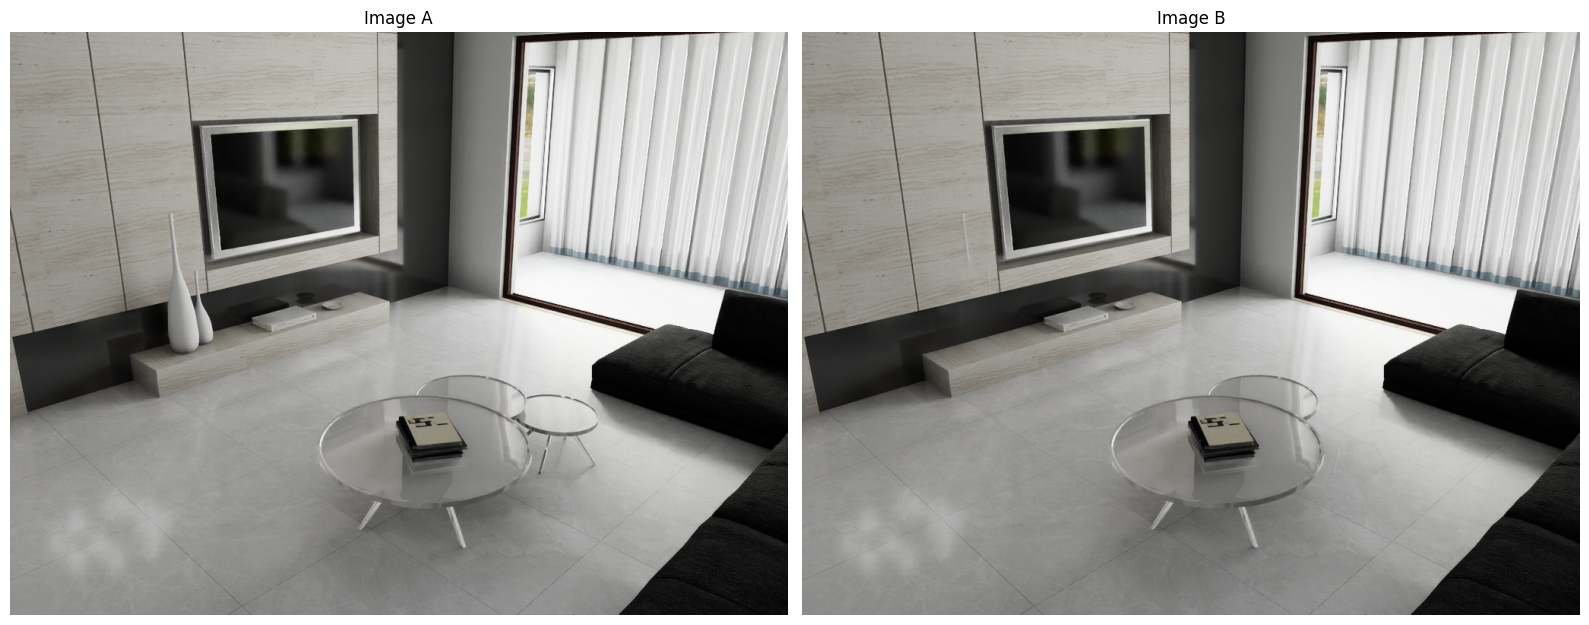

In [10]:
# 显示图片A/B（可选，用于肉眼对比；不影响 remove 主流程只用 A 图推理）
import matplotlib.pyplot as plt

if pair_folders:
    first_pair = pair_folders[0]

    img_a = plt.imread(first_pair / "A_rgb.png")

    # B 可能不存在（取决于你的数据组织），不存在则只展示 A
    b_path = first_pair / "B_rgb.png"
    img_b = plt.imread(b_path) if b_path.exists() else None

    if img_b is None:
        plt.figure(figsize=(8, 6))
        plt.imshow(img_a)
        plt.title("Image A")
        plt.axis("off")
        plt.tight_layout()
        plt.show()
    else:
        fig, axes = plt.subplots(1, 2, figsize=(16, 8))

        axes[0].imshow(img_a)
        axes[0].set_title("Image A")
        axes[0].axis("off")

        axes[1].imshow(img_b)
        axes[1].set_title("Image B")
        axes[1].axis("off")

        plt.tight_layout()
        plt.show()